we are going to do a mini project on titanic - 1st without pipelines , and 2nd with pipelines

-----
-----

# 1} Without Pipelines

In [1]:
import numpy as np                                  #for linear algebra and numpy array and it's application
import pandas as pd                                 #for data processing and data handling

from sklearn.impute import SimpleImputer            #for missing values
from sklearn.preprocessing import OneHotEncoder     #for nominal categorical data
from sklearn.preprocessing import MinMaxScaler      #for  scaling in range [0,1]
from sklearn.tree import DecisionTreeClassifier     #for doing prediction

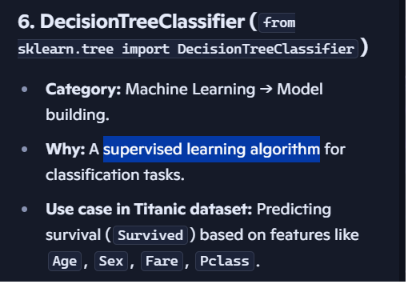
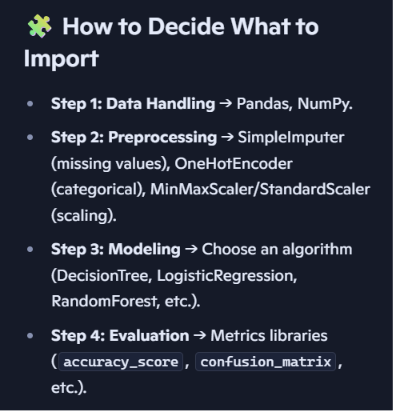

### Copilot Help Link
[Return to this Copilot chat](https://copilot.microsoft.com/conversations/join/eGz6tpjyjyXE1wLVpLjRj)

In [2]:
df = pd.read_csv(r"D:\ML\DataSet\Titanic_Dataset.csv")

In [3]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5000,B79,S


In [4]:
#for now we dont have any use of 4 columns , passengerID, name , Ticket No. , and Cabin - we are just learning to use this 

df.drop(columns = ['PassengerId','Name','Ticket','Cabin'] , inplace= True)

In [5]:
df.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
21,1,2,male,34.0,0,0,13.00,S
75,0,3,male,25.0,0,0,7.65,S
348,1,3,male,3.0,1,1,15.90,S


In [6]:
#step:1 -> train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [7]:
X_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [8]:
y_train.head(2)

331    0
733    0
Name: Survived, dtype: int64

In [9]:
df.isnull().sum(numeric_only=True)      #used to find the no. of missing values across all the given columns 

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [10]:
#step:2 -> Before we move forward we have to fill the missing values

#Apply Imputation

si_age = SimpleImputer()        #by default it's strategy is mean
si_embarked = SimpleImputer(strategy='most_frequent')       #this will fill the missing data with most frequently occuring values in embarked column

X_train_age = si_age.fit_transform(X_train[['Age']])
X_train_embarked = si_embarked.fit_transform(X_train[['Embarked']])
X_train_embarked = pd.DataFrame(X_train_embarked, columns=['Embarked'])     #error in total columns so this line is added

X_test_age = si_age.transform(X_test[['Age']])
X_test_embarked = si_embarked.transform(X_test[['Embarked']])
X_test_embarked = pd.DataFrame(X_test_embarked, columns=['Embarked'])       #error in total columns so this line is added

we will not apply the OHE on both columns simultaneously as the changes are not made in the original data frame 

In [11]:
#step:3 -> now we have to change the categorical data from sex and embarked using ohe

ohe_sex = OneHotEncoder(sparse_output=False , handle_unknown='ignore')
ohe_embarked = OneHotEncoder(sparse_output=False , handle_unknown='ignore')

X_train_sex = ohe_sex.fit_transform(X_train[['Sex']])
X_train_embarked = ohe_embarked. fit_transform(X_train_embarked)

X_test_sex = ohe_sex.transform(X_test[['Sex']])
X_test_embarked = ohe_embarked. transform(X_test_embarked)

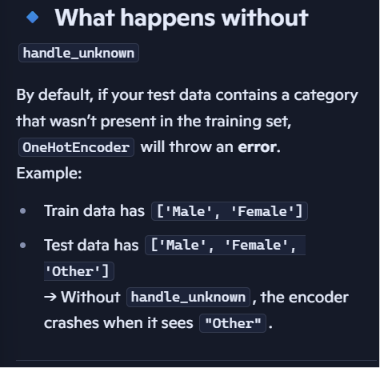

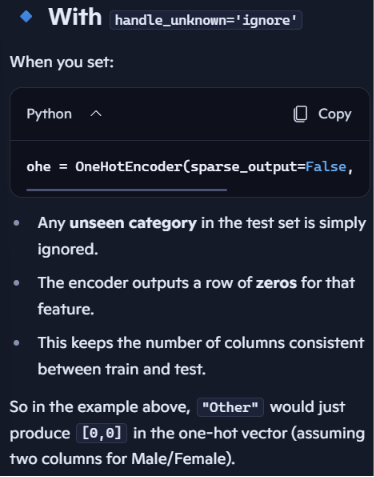

In [12]:
X_train_sex

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [0., 1.]], shape=(712, 2))

we have not removed the first column as we are implementing decision tree which is not linear so, it will not have any problem

In [13]:
X_train_remaining = X_train.drop(columns=['Sex','Embarked','Age'])
X_test_remaining = X_test.drop(columns=['Sex','Embarked','Age'])

In [14]:
X_train_transformed = np.concatenate((X_train_remaining, X_train_age,X_train_sex,X_train_embarked), axis=1)
X_test_transformed = np.concatenate((X_test_remaining, X_test_age,X_test_sex,X_test_embarked), axis=1)

In [15]:
X_train_transformed.shape

(712, 10)

In [16]:
clf = DecisionTreeClassifier()      # initializes the Decision Tree model
clf.fit(X_train_transformed, y_train)   # trains (fits) the model on training data

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [17]:
y_predict = clf.predict(X_test_transformed)

In [18]:
y_predict

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1])

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.770949720670391

----
----

### now, let's say we have to make it deployed on the web server or something like that . How to do ? Let's find out!

We are going to deploy it on a webpag ewhere we will be having a form on which we will be having Pclass, Sex, etc. data

our model will take the input and then predict whether that person will survive or not.

for exporting the model we uses a library known as pickle and use a dump function to make it in exportable form. 

In [20]:
import pickle

In [21]:
pickle.dump(ohe_sex, open('D:/ML/Codes/models/Day29/ohe_sex.pkl','wb'))
pickle.dump(ohe_embarked,open('D:/ML/Codes/models/Day29/ohe_embarked.pkl','wb'))
pickle.dump(clf,open('D:/ML/Codes/models/Day29/clf.pkl','wb'))

IMPORTANT

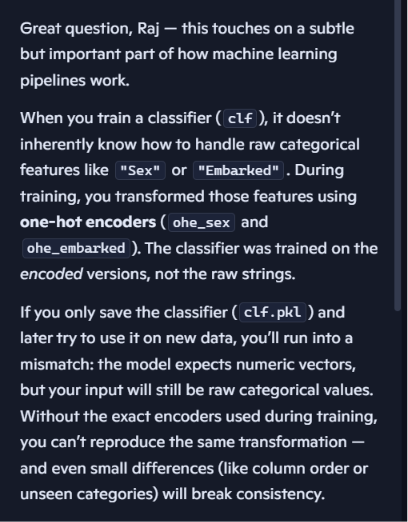

-----
-----

# Predicting without Pipelines
    -> since, we dont know about deploying it we will be making it like a new folder  from here on which will behave as website for further use

In [23]:
import pickle
import numpy as np

In [24]:
#in the coding and uploading we have converted into pickle data , now it's the time to decode it

ohe_sex = pickle.load(open('D:/ML/Codes/models/Day29/ohe_sex.pkl','rb'))
ohe_embarked = pickle.load(open('D:/ML/Codes/models/Day29/ohe_embarked.pkl','rb'))
clf = pickle.load(open('D:/ML/Codes/models/Day29/clf.pkl','rb'))

In [26]:
# Assume user input
# Pclass/sex/age/SibSp/Parch/Fare/Embarked
test_input = np.array([2, 'female', 32.0, 1, 0, 16.9, 'S'],dtype=object).reshape(1,7)

In [27]:
test_input

array([[2, 'female', 32.0, 1, 0, 16.9, 'S']], dtype=object)

In [30]:
test_input_sex = ohe_sex.transform(test_input[:,1].reshape(1,1))


d:\ML\ML_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [33]:
test_input_sex

array([[1., 0.]])

In [31]:
test_input_embarked = ohe_embarked. transform(test_input[:,-1].reshape(1,1))

d:\ML\ML_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [34]:
test_input_embarked

array([[0., 0., 1.]])

In [32]:
test_input_age = test_input[:,2].reshape(1,1)

In [35]:
test_input_transformed = np.concatenate((test_input[:,[0,3,4,5]],test_input_age,test_input_sex,test_input_embarked),axis=1)

In [36]:
test_input_transformed.shape

(1, 10)

In [37]:
clf.predict(test_input_transformed)

array([1])

now, here we can see that we have to do the whole work 2 times. 1 while making and other while on the webpage.

hence, to aboid these many step we use the pipelines.

see Day29_B.ipynb for further study using pipelines

-----
-----